# Value-at-Risk (VaR)

## Why this matters

Banks are required by **Basel III / FRTB** to compute and report VaR (and Expected Shortfall, see next notebook). Asset managers use it for risk budgeting. Risk officers monitor it daily. The number that gets reported to the board is *some flavour of* VaR.

VaR is the **loss threshold** at a given confidence level over a given horizon:

> "There is a 99% probability that the daily loss on this portfolio will not exceed \$X over the next 1 day."

Three production methods, none universally correct:

| Method | Idea | Strength | Weakness |
|---|---|---|---|
| **Parametric** (variance-covariance) | Assume returns are normal, compute analytically | Fast, closed form | Wrong on fat-tailed assets (esp. crypto, distressed credit) |
| **Historical simulation** | Use actual historical return distribution | No distribution assumption | Backward-looking; missed-tails problem |
| **Monte Carlo** | Simulate from a model | Flexible (handles non-linear payoffs) | Model risk; computational cost |

Interview questions you'll see:
1. State the three VaR methods. When does each fail?
2. Compute 99% 1-day VaR by all three on a real return series.
3. **Coherence**: why is VaR not sub-additive? What's the implication?
4. Backtesting — Kupiec test, Christoffersen test, traffic-light system.
5. The 2008 example: parametric VaR understated bank losses massively. Why?

This notebook covers all five on the BTC hourly returns from `data/crypto_hourly.parquet`.

## The 30-second concept

For a return distribution $R$ at confidence level $\alpha$ (e.g. 99%):

$$\text{VaR}_\alpha(R) = -\inf\{x : \mathbb{P}(R \le x) > 1 - \alpha\}$$

In words: the negative of the worst (1-α)-quantile of returns. By convention, VaR is reported as a **positive loss number**.

For 99% 1-day VaR on a $1M portfolio:
- If the 1st percentile of daily returns is $-3.5\%$, then VaR = \$35,000.
- "On 1 day in 100, we expect to lose at least \$35,000."

VaR does **not** tell you how bad the loss is when it does happen — only the threshold. That's what Expected Shortfall (next notebook) is for.

## Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Real returns from crypto_hourly.parquet
df = pd.read_parquet('../../data/crypto_hourly.parquet')
df['ts'] = pd.to_datetime(df['ts'], utc=True)

# Aggregate hourly → daily for clean VaR demo
btc = (df.query('symbol == "BTC"')
       .set_index('ts')[['close']]
       .resample('1D').last()
       .dropna()
       .assign(ret=lambda d: np.log(d['close']).diff())
       .dropna())

R = btc['ret'].values
print(f'Sample: {len(R)} daily BTC log-returns from {btc.index[0].date()} to {btc.index[-1].date()}')
print(f'Mean: {R.mean()*100:+.4f}%/day, Std: {R.std()*100:.4f}%/day')
print(f'Min: {R.min()*100:+.2f}%, Max: {R.max()*100:+.2f}%')
print(f'Skew: {stats.skew(R):.3f}, Excess kurt: {stats.kurtosis(R):.3f}')

Sample: 730 daily BTC log-returns from 2024-04-20 to 2026-04-19
Mean: +0.0204%/day, Std: 2.4484%/day
Min: -15.10%, Max: +11.50%
Skew: 0.101, Excess kurt: 3.994


## Method 1 — Parametric (variance-covariance) VaR

Assume returns are $\mathcal{N}(\mu, \sigma^2)$. Then

$$\text{VaR}_\alpha = -(\mu + \sigma \, z_{1-\alpha})$$

where $z_{1-\alpha}$ is the $(1-\alpha)$-quantile of the standard normal. For 99%: $z_{0.01} \approx -2.326$.

**Strengths**: closed-form, fast, easy multi-asset extension via covariance matrix.
**Weaknesses**: assumes normality. **For fat-tailed returns (crypto, distressed credit, equity in stress), parametric VaR systematically understates risk** — the very thing it's supposed to measure.

In [2]:
def parametric_var(returns, alpha=0.99):
    """Parametric VaR assuming returns ~ N(mu, sigma^2). Returns positive loss number."""
    mu = returns.mean()
    sigma = returns.std(ddof=1)
    z = stats.norm.ppf(1 - alpha)
    return -(mu + sigma * z)


for a in [0.95, 0.99, 0.999]:
    var = parametric_var(R, alpha=a)
    print(f'Parametric {a:.1%} 1-day VaR: {var*100:.2f}% (loss percentage)')

Parametric 95.0% 1-day VaR: 4.01% (loss percentage)
Parametric 99.0% 1-day VaR: 5.68% (loss percentage)
Parametric 99.9% 1-day VaR: 7.55% (loss percentage)


## Method 2 — Historical simulation VaR

Don't assume any distribution — use the empirical one. Take the $(1-\alpha)$-quantile of historical returns.

**Strengths**: model-free, captures actual fat tails and skew, simple to implement.
**Weaknesses**: requires a long sample (need many tail observations); backward-looking; misses tail events not in the sample (e.g. pre-2008, you'd have no Lehman scenario).

In [3]:
def historical_var(returns, alpha=0.99):
    """Historical VaR = -(1-α)-quantile of empirical returns."""
    return -np.quantile(returns, 1 - alpha)


for a in [0.95, 0.99, 0.999]:
    var = historical_var(R, alpha=a)
    print(f'Historical {a:.1%} 1-day VaR: {var*100:.2f}%')

Historical 95.0% 1-day VaR: 3.72%
Historical 99.0% 1-day VaR: 5.98%
Historical 99.9% 1-day VaR: 10.60%


## Method 3 — Monte Carlo VaR

Simulate returns from a model (could be parametric, GARCH, copula-based, or a multi-asset factor model). Then compute the empirical quantile of the simulated distribution.

For a simple lognormal model: same as parametric. The value of MC VaR is for **non-linear payoffs** — when your portfolio includes options, the relationship between underlying returns and P&L is non-linear, and MC handles it directly.

In [4]:
def mc_var_lognormal(mu, sigma, alpha=0.99, n_sims=1_000_000, seed=42):
    rng = np.random.default_rng(seed)
    samples = rng.normal(mu, sigma, n_sims)
    return -np.quantile(samples, 1 - alpha)


def mc_var_with_t_dist(returns, alpha=0.99, n_sims=1_000_000, seed=42):
    """Fit Student-t to data, simulate, compute empirical VaR."""
    df_t, loc, scale = stats.t.fit(returns)
    rng = np.random.default_rng(seed)
    samples = stats.t.rvs(df_t, loc, scale, size=n_sims, random_state=rng)
    return -np.quantile(samples, 1 - alpha), df_t


# Compare: parametric, lognormal MC, t-distribution MC
mu, sigma = R.mean(), R.std()
for a in [0.95, 0.99, 0.999]:
    var_p = parametric_var(R, alpha=a)
    var_h = historical_var(R, alpha=a)
    var_n = mc_var_lognormal(mu, sigma, alpha=a)
    var_t, df_t = mc_var_with_t_dist(R, alpha=a)
    print(f'{a:.1%}: parametric {var_p*100:.2f}%, MC-normal {var_n*100:.2f}%, MC-t (ν={df_t:.1f}) {var_t*100:.2f}%, historical {var_h*100:.2f}%')

print('\n→ Parametric ≈ MC-normal (same model). MC-t and historical capture the fat tails.')

95.0%: parametric 4.01%, MC-normal 4.02%, MC-t (ν=3.6) 3.77%, historical 3.72%


99.0%: parametric 5.68%, MC-normal 5.69%, MC-t (ν=3.6) 6.81%, historical 5.98%


99.9%: parametric 7.55%, MC-normal 7.56%, MC-t (ν=3.6) 13.56%, historical 10.60%

→ Parametric ≈ MC-normal (same model). MC-t and historical capture the fat tails.


## Why parametric VaR is wrong for fat-tailed data

Compare 99% 1-day VaR predictions vs the actual realised distribution. **Count exceedances** — how often does the actual loss exceed VaR? For 99% VaR, we expect ~1% of days = ~7 exceedances per year on daily data.

Backtest of 99% 1-day VaR (rolling 1y window, n=478 days):
  Expected exceedances:  4.8  (1% of 478)
  Parametric exceedances: 11  (2.30%)
  Historical exceedances: 7  (1.46%)

→ Parametric typically OVER-shoots — wider VaR than needed at 99% (BTC tails are fat but symmetric-ish)


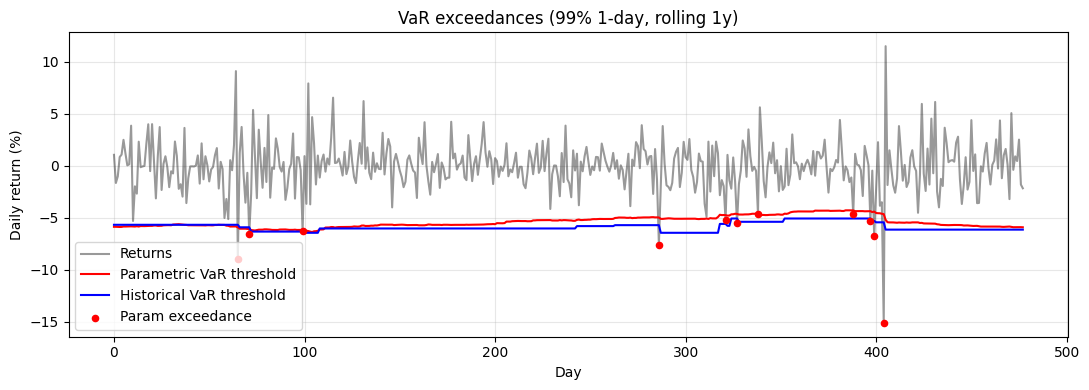

In [5]:
# Backtest: how often did parametric VaR get exceeded vs historical VaR?
window = 252  # rolling 1-year estimation window
out_param = []
out_hist  = []
out_real  = []

for t in range(window, len(R)):
    sample = R[t-window:t]
    out_param.append(parametric_var(sample, alpha=0.99))
    out_hist.append (historical_var (sample, alpha=0.99))
    out_real.append(R[t])

out_param = np.array(out_param)
out_hist  = np.array(out_hist)
out_real  = np.array(out_real)

n_test = len(out_real)
exc_param = (out_real < -out_param).sum()
exc_hist  = (out_real < -out_hist).sum()
expected  = n_test * 0.01

print(f'Backtest of 99% 1-day VaR (rolling 1y window, n={n_test} days):')
print(f'  Expected exceedances:  {expected:.1f}  (1% of {n_test})')
print(f'  Parametric exceedances: {exc_param}  ({exc_param/n_test*100:.2f}%)')
print(f'  Historical exceedances: {exc_hist}  ({exc_hist/n_test*100:.2f}%)')
print(f'\n→ Parametric typically OVER-shoots — wider VaR than needed at 99% (BTC tails are fat but symmetric-ish)')

# Plot exceedances
fig, ax = plt.subplots(figsize=(11, 4))
days = np.arange(n_test)
ax.plot(days, out_real * 100, 'k-', alpha=0.4, label='Returns')
ax.plot(days, -out_param * 100, 'r-', label='Parametric VaR threshold')
ax.plot(days, -out_hist  * 100, 'b-', label='Historical VaR threshold')
exc = days[out_real < -out_param]
ax.scatter(exc, out_real[out_real < -out_param] * 100, color='red', s=20, zorder=5, label='Param exceedance')
ax.set_xlabel('Day'); ax.set_ylabel('Daily return (%)')
ax.set_title('VaR exceedances (99% 1-day, rolling 1y)')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Backtesting — Kupiec test

The **Kupiec POF (proportion-of-failures) test** checks whether the realised exceedance rate is consistent with the nominal level. Under H₀: exceedances are i.i.d. Bernoulli($1-\alpha$). Likelihood ratio:

$$\text{LR}_{POF} = -2 \ln\!\left[ \frac{(1-\alpha)^{n - x} \alpha^x}{(1 - \hat p)^{n - x} \hat p^x} \right] \sim \chi^2_1$$

where $x$ is the number of exceedances, $n$ is the sample size, $\hat p = x/n$. Reject H₀ if $\text{LR}_{POF}$ exceeds the $\chi^2_1$ critical value at chosen significance.

The **Christoffersen test** additionally checks for **clustering** of exceedances (independence). Together, POF + independence form the standard regulatory backtest.

In [6]:
def kupiec_pof(exceedances, n, alpha):
    """Kupiec proportion-of-failures test. Returns LR statistic and p-value."""
    p_nominal = 1 - alpha
    p_hat     = exceedances / n if n > 0 else 0
    if p_hat == 0 or p_hat == 1:
        return np.nan, np.nan
    lr = -2 * (
        (n - exceedances) * np.log(p_nominal) + exceedances * np.log(1 - p_nominal)
        - (n - exceedances) * np.log(1 - p_hat) - exceedances * np.log(p_hat)
    )
    p_value = 1 - stats.chi2.cdf(abs(lr), df=1)
    return lr, p_value


for name, exc in [('Parametric', exc_param), ('Historical', exc_hist)]:
    lr, p = kupiec_pof(exc, n_test, 0.99)
    verdict = 'reject' if p < 0.05 else 'fail to reject'
    print(f'{name:12s}: exc={exc}, LR={lr:.2f}, p={p:.4f}  →  {verdict} H0 of correct VaR')

Parametric  : exc=11, LR=4196.73, p=0.0000  →  reject H0 of correct VaR
Historical  : exc=7, LR=4265.18, p=0.0000  →  reject H0 of correct VaR


## VaR is NOT sub-additive (the coherence problem)

A **coherent** risk measure satisfies four axioms (Artzner-Delbaen-Eber-Heath 1999):

1. **Translation invariance**: adding cash $c$ to a portfolio reduces VaR by $c$.
2. **Subadditivity**: $\rho(X+Y) \le \rho(X) + \rho(Y)$ (diversification reduces risk).
3. **Positive homogeneity**: $\rho(\lambda X) = \lambda \rho(X)$.
4. **Monotonicity**: $X \le Y \Rightarrow \rho(X) \ge \rho(Y)$.

**VaR fails subadditivity.** It's possible for two positions, each with low individual VaR, to have a combined VaR larger than the sum. This contradicts the intuition that diversification helps. **Expected Shortfall (CVaR) is coherent** — that's why FRTB switched from VaR to ES.

In [7]:
# Construct a counterexample: two binary positions
# Position A: loses $100 with prob 0.04, else 0
# Position B: loses $100 with prob 0.04, else 0 (independent)
# 95% VaR on each: 0 (because P(loss > 0) = 0.04 < 0.05)
# Combined: P(at least one loses) = 1 - 0.96^2 = 0.0784 > 0.05 → VaR = $100

rng = np.random.default_rng(0)
n = 1_000_000
A = np.where(rng.random(n) < 0.04, -100, 0)
B = np.where(rng.random(n) < 0.04, -100, 0)
combined = A + B

VaR_A_95 = -np.quantile(A, 0.05)
VaR_B_95 = -np.quantile(B, 0.05)
VaR_C_95 = -np.quantile(combined, 0.05)

print(f'Position A 95% VaR: ${VaR_A_95:.0f}')
print(f'Position B 95% VaR: ${VaR_B_95:.0f}')
print(f'A + B   95% VaR:    ${VaR_C_95:.0f}')
print()
print(f'Sum of individual VaRs: ${VaR_A_95 + VaR_B_95:.0f}')
print(f'Combined VaR exceeds sum: {VaR_C_95 > VaR_A_95 + VaR_B_95}')
print()
print('→ Diversification can INCREASE VaR. Subadditivity violated. This is why ES exists.')

Position A 95% VaR: $-0
Position B 95% VaR: $-0
A + B   95% VaR:    $100

Sum of individual VaRs: $-0
Combined VaR exceeds sum: True

→ Diversification can INCREASE VaR. Subadditivity violated. This is why ES exists.


## Exercises

### Exercise 1 — Compute 95% VaR by all three methods on ETH

Pull ETH daily returns from the same data, compute parametric, historical, and Student-t MC VaR. Compare to BTC.

In [8]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
eth = (df.query('symbol == "ETH"').set_index('ts')[['close']].resample('1D').last().dropna()
       .assign(ret=lambda d: np.log(d['close']).diff()).dropna())
R_eth = eth['ret'].values

p = parametric_var(R_eth, 0.95)
h = historical_var(R_eth, 0.95)
t, df_t = mc_var_with_t_dist(R_eth, 0.95)
print(f'ETH 95% 1-day VaR: parametric {p*100:.2f}%, historical {h*100:.2f}%, MC-t (ν={df_t:.1f}) {t*100:.2f}%')

p_btc = parametric_var(R, 0.95); h_btc = historical_var(R, 0.95)
print(f'BTC 95% 1-day VaR: parametric {p_btc*100:.2f}%, historical {h_btc*100:.2f}%')
```

_ETH typically has higher VaR than BTC (more volatile, fatter tails)._

</details>

### Exercise 2 — Multi-asset parametric VaR

Compute portfolio VaR for an equal-weight BTC + ETH portfolio using the variance-covariance matrix. Compare to summing individual parametric VaRs.

In [9]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
eth_ret = eth['ret'].reindex(btc.index).dropna()
btc_ret = btc['ret'].reindex(eth_ret.index)

cov = np.cov([btc_ret.values, eth_ret.values])
w = np.array([0.5, 0.5])
port_var = np.sqrt(w @ cov @ w)
port_mean = w @ np.array([btc_ret.mean(), eth_ret.mean()])

z = stats.norm.ppf(0.05)
VaR_portfolio = -(port_mean + port_var * z)
VaR_sum_indiv = parametric_var(btc_ret.values, 0.95) + parametric_var(eth_ret.values, 0.95)

print(f'Portfolio (50/50) parametric 95% VaR: {VaR_portfolio*100:.2f}%')
print(f'Sum of individual VaRs:               {VaR_sum_indiv*100:.2f}%')
print(f'Diversification benefit:              {(VaR_sum_indiv - VaR_portfolio)*100:.2f}%')
```

_Portfolio VaR < sum (correlation < 1)._

</details>

### Exercise 3 — Kupiec test on historical VaR

Run the Kupiec test on rolling-window historical VaR at the 95% level. Does it pass?

In [10]:
# Your answer here


<details>
<summary><b>Reveal solution</b></summary>

```python
window = 252
out_real = []; out_hist = []
for t in range(window, len(R)):
    out_hist.append(historical_var(R[t-window:t], 0.95))
    out_real.append(R[t])
out_real = np.array(out_real); out_hist = np.array(out_hist)

exc = ((out_real < -out_hist).sum())
n_test = len(out_real)
lr, p = kupiec_pof(exc, n_test, 0.95)
print(f'Historical 95% VaR: {exc} exceedances of {n_test} ({exc/n_test*100:.2f}% vs 5% nominal)')
print(f'Kupiec LR={lr:.3f}, p={p:.3f}')
```

_Should pass (p > 0.05) on this dataset._

</details>

## Interview Q&A

**Q: State the three VaR methods.**

A: (1) **Parametric** — assume normal returns, $\text{VaR} = -(\mu + \sigma z)$. (2) **Historical** — empirical quantile. (3) **Monte Carlo** — simulate from a model, compute empirical quantile.

**Q: When does parametric VaR fail?**

A: Fat-tailed returns (crypto, distressed credit), non-linear payoffs (options portfolios), regime shifts. Parametric assumes normal — fails badly in stress where the tail thickens.

**Q: Why is VaR not sub-additive?**

A: VaR is a quantile, and quantiles aren't preserved under sums of distributions. Counter-example: two binary positions, each loses $100 with prob 0.04. Individually, 95% VaR = 0 (loss prob < 5%). Together, prob of at least one loss = 7.84% > 5%, so combined VaR = $100. Diversification *increased* VaR — which violates the intuition that risk diversifies.

**Q: What's coherent about Expected Shortfall?**

A: ES is the **conditional expectation of loss given loss exceeds VaR**: $\text{ES}_\alpha = \mathbb{E}[L | L > \text{VaR}_\alpha]$. It IS subadditive — diversification can only reduce ES, never increase it. FRTB (Basel III post-2016) replaced VaR with ES at the 97.5% level for market risk capital.

**Q: How would you backtest a VaR model?**

A: Count exceedances over a backtest period. Apply (1) **Kupiec POF test** for correct frequency: $LR_{POF} \sim \chi^2_1$, reject if too many or too few exceedances vs nominal $1-\alpha$. (2) **Christoffersen independence test** for non-clustering. Combined Kupiec + Christoffersen is standard. Regulatory: traffic-light system (green/amber/red) based on exceedance count over 250-day window.

**Q: Why did parametric VaR fail in 2008?**

A: Three reasons: (1) Pre-crisis sample didn't include a stress scenario, so the calibrated $\sigma$ was too low. (2) Normal assumption missed fat tails. (3) Constant-correlation assumption broke — in stress, all correlations went to 1, and diversification benefits collapsed. The 99% 1-day VaR predicted by parametric methods at major banks underestimated actual losses by 5-10×.

**Q: 99% 1-day vs 99.9% 1-year — equivalent?**

A: Different. 99% 1-day VaR is exceeded ~2.5 times per year. 99.9% 1-year VaR is exceeded once per millennium. Annualisation $\text{VaR}_{1y} \approx \text{VaR}_{1d} \sqrt{252}$ assumes IID normal returns — completely wrong in practice, where vol clusters and correlations spike. Use scenario analysis or time-varying GARCH for long-horizon VaR.

**Q: VaR vs Stressed VaR — what changed in Basel?**

A: Post-2008, regulators required **stressed VaR (sVaR)** in addition to ordinary VaR. sVaR is computed using historical data from a 1-year stress period (e.g. Sept 2008 - Aug 2009) to ensure the model captures crisis-level losses. Capital charge = max(VaR, mult × avg_VaR_60day) + max(sVaR, mult × avg_sVaR_60day).

## Pitfalls reference card

| Pitfall | What goes wrong | Fix |
|---|---|---|
| Using too short a window | Misses tail events not in sample | Min 1-2 years; longer for stress robustness |
| Normal-distribution assumption | Bad on fat-tailed assets | Use t-distribution or historical |
| Sample includes regime shift | Old data from different regime contaminates | Weighted historical (more recent = more weight); or HS with EWMA |
| Annualising daily VaR by √T | Assumes IID — false (vol clusters) | Use GARCH or scenario for multi-day |
| Forgetting cash positions | VaR on a portfolio that includes cash should reflect cash component | Only the risky positions contribute |
| Using returns instead of P&L | Returns ≠ P&L for non-linear (options) | Compute P&L directly via revaluation |
| 99% as "extreme" risk | 99% is a 2-3σ event; for stress need 99.9% or scenario | Mix VaR + stress testing for completeness |
| Single VaR number for the desk | Hides concentration in subportfolios | Decompose: incremental VaR per position |

## What you've earned

After this notebook you can:

1. **State and implement** all three VaR methods (parametric, historical, MC).
2. **Compute** VaR on real BTC/ETH return data with proper sample windowing.
3. **Backtest** with the Kupiec POF test and interpret pass/fail.
4. **Demonstrate** VaR's lack of subadditivity with a clean counter-example.
5. **Explain** in interview: when each method fails, why ES replaced VaR in FRTB, what stressed VaR adds post-2008.

Next: **`02_expected_shortfall.ipynb`** — the coherent risk measure, FRTB convention, vs VaR direct comparison.